# Olist E-Commerce Customer Segmentation

**Goal:** Group customers into meaningful behavioral segments using their purchase history from the Olist Brazilian e-commerce dataset.

**Why it matters:** Not all customers are equal. A business that treats a customer who bought once for $20 the same way as one who spent $300 recently is wasting marketing spend. Segmentation lets teams send the right message to the right group at the right time.

**Approach:** RFM (Recency, Frequency, Monetary) analysis combined with K-Means clustering. Each customer is described by how recently they bought, how often, and how much they spent total. The model then groups similar customers together with no predefined labels.

**Type:** Unsupervised learning. There is no target column. The algorithm finds natural groupings on its own.

**Challenge:** Frequency had near-zero variance in this dataset (over 90% of customers bought exactly once), making it uninformative for clustering. It was dropped and the model was built on Recency and Monetary only.

&nbsp;

| Step | Details |
|---|---|
| Dataset | Olist Brazilian E-Commerce, 3 joined tables, 93,358 unique customers |
| Features used | Recency (days since last order), Monetary (total spend) |
| Outlier removal | IQR method, 10,112 rows removed |
| Preprocessing | Log transform + StandardScaler |
| Algorithm | K-Means |
| Optimal K | 3 (Elbow method + Silhouette score) |
| Silhouette score | 0.4129 at K=3 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')


In [3]:
print(customers.shape)
print(orders.shape)
print(items.shape)

(99441, 5)
(99441, 8)
(112650, 7)


In [4]:
# Step 1: join orders with items on order_id
orders_items = orders.merge(items, on='order_id', how='inner')

# Step 2: join result with customers on customer_id
full = orders_items.merge(customers, on='customer_id', how='inner')

# Step 3: filter delivered orders only
full = full[full['order_status'] == 'delivered']

In [5]:
print(full.shape)
print(full.columns.tolist())

(110197, 18)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [6]:
# Convert timestamp to datetime
full['order_purchase_timestamp'] = pd.to_datetime(full['order_purchase_timestamp'])

# Reference date: one day after the last purchase in the dataset
reference_date = full['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Aggregate to customer level
rfm = full.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),       # unique orders, not items
    monetary  = ('price', 'sum')               # total spend
).reset_index()

In [7]:
rfm

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00
...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,1570.00
93354,fffea47cd6d3cc0a88bd621562a9d061,262,1,64.89
93355,ffff371b4d645b6ecea244b27531430a,568,1,89.90
93356,ffff5962728ec6157033ef9805bacc48,119,1,115.00


In [8]:
print(rfm.shape)
print(rfm.describe())

(93358, 4)
            recency     frequency      monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    141.621480
std      152.591453      0.209097    215.694014
min        1.000000      1.000000      0.850000
25%      114.000000      1.000000     47.650000
50%      219.000000      1.000000     89.730000
75%      346.000000      1.000000    154.737500
max      714.000000     15.000000  13440.000000


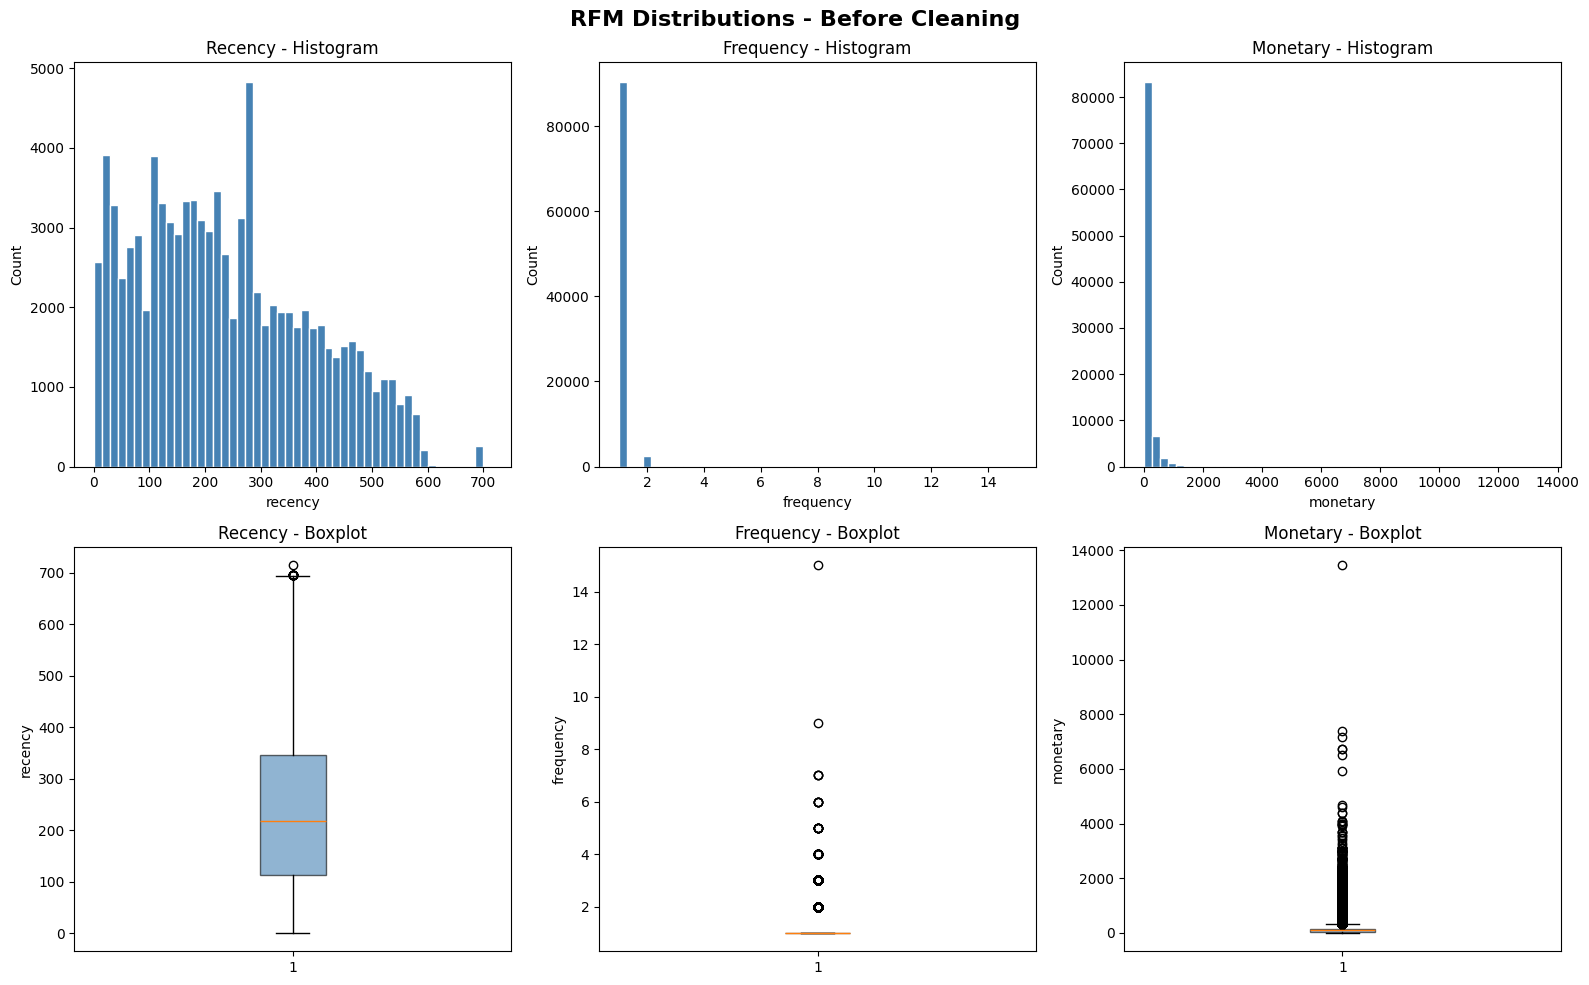

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('RFM Distributions - Before Cleaning', fontsize=16, fontweight='bold')

cols = ['recency', 'frequency', 'monetary']

# Row 1: Histograms
for i, col in enumerate(cols):
    axes[0, i].hist(rfm[col], bins=50, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col.capitalize()} - Histogram')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

for i, col in enumerate(cols):
    axes[1, i].boxplot(rfm[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f'{col.capitalize()} - Boxplot')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()    

In [10]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after = len(df_clean)
        print(f"{col}: removed {before - after} outliers ({before} → {after} rows)")
    return df_clean

rfm_clean = remove_outliers_iqr(rfm, ['recency', 'frequency', 'monetary'])
print(f"\nFinal shape: {rfm_clean.shape}")

recency: removed 26 outliers (93358 → 93332 rows)
frequency: removed 2801 outliers (93332 → 90531 rows)
monetary: removed 7285 outliers (90531 → 83246 rows)

Final shape: (83246, 4)


In [11]:
rfm_log = rfm_clean.copy()

rfm_log['recency']   = np.log1p(rfm_clean['recency'])
rfm_log['frequency'] = np.log1p(rfm_clean['frequency'])
rfm_log['monetary']  = np.log1p(rfm_clean['monetary'])

# np.log1p means log(1 + x), which safely handles values of 0

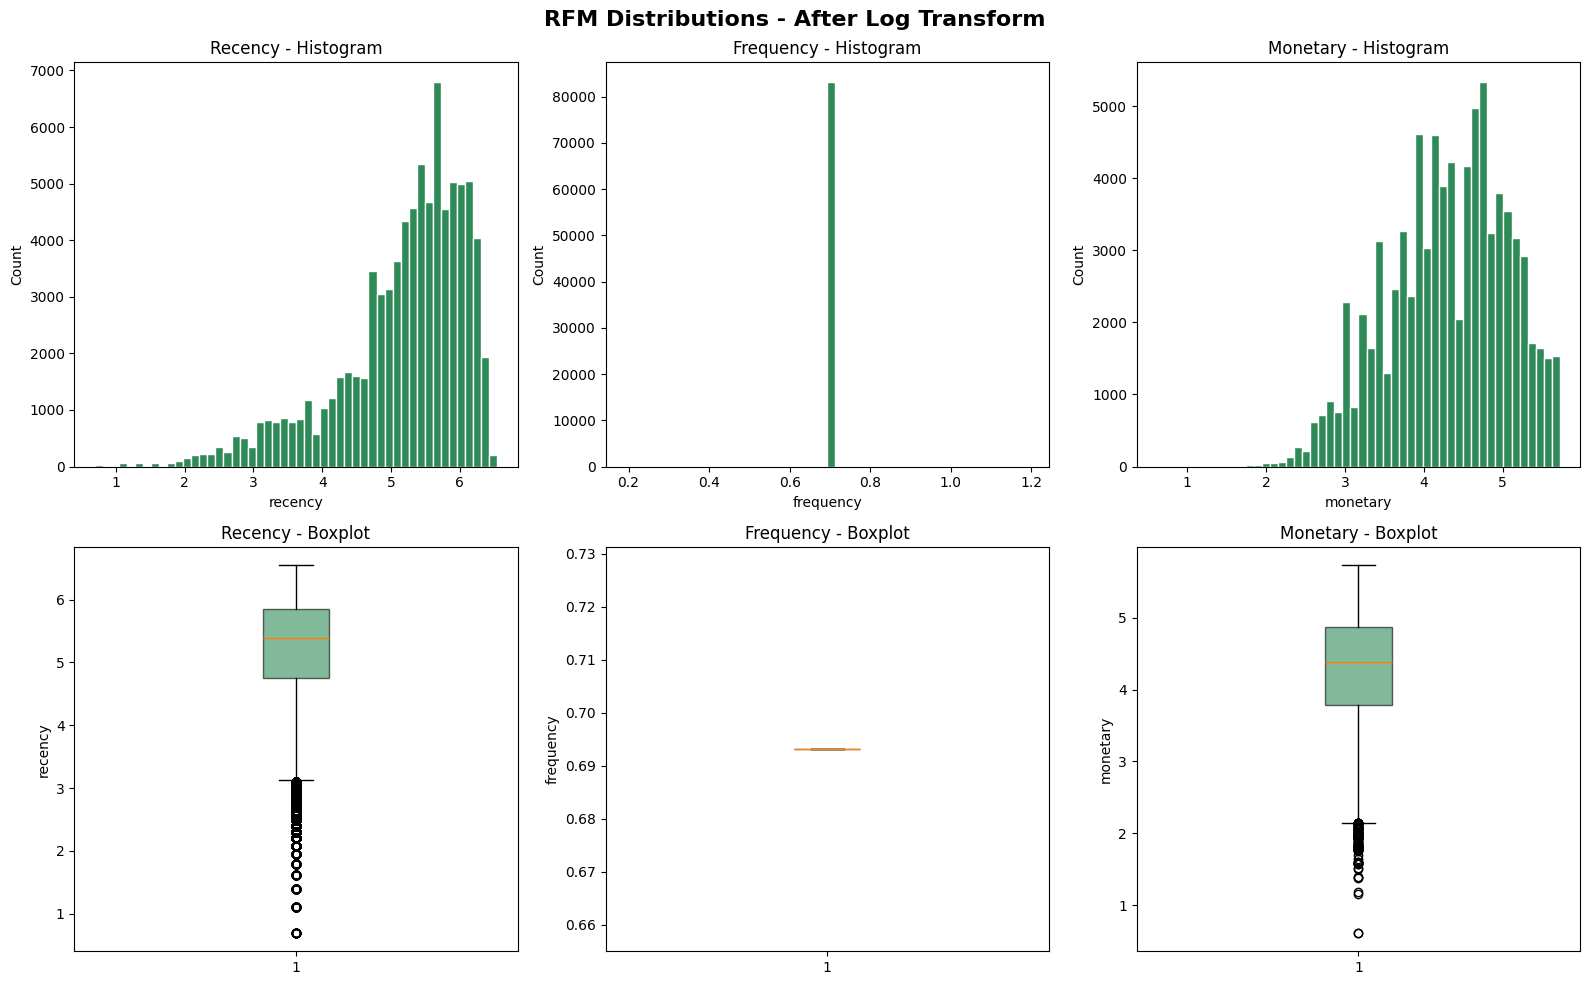

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('RFM Distributions - After Log Transform', fontsize=16, fontweight='bold')

cols = ['recency', 'frequency', 'monetary']

for i, col in enumerate(cols):
    axes[0, i].hist(rfm_log[col], bins=50, color='seagreen', edgecolor='white')
    axes[0, i].set_title(f'{col.capitalize()} - Histogram')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

for i, col in enumerate(cols):
    axes[1, i].boxplot(rfm_log[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='seagreen', alpha=0.6))
    axes[1, i].set_title(f'{col.capitalize()} - Boxplot')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['recency', 'frequency', 'monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['recency', 'frequency', 'monetary'])

print(rfm_scaled.describe().round(2))

        recency  frequency  monetary
count  83246.00    83246.0  83246.00
mean       0.00        0.0      0.00
std        1.00        0.0      1.00
min       -4.79        0.0     -4.87
25%       -0.44        0.0     -0.68
50%        0.24        0.0      0.11
75%        0.73        0.0      0.76
max        1.47        0.0      1.88


In [14]:
# Dropping the frequency because itr have no variation(most of the customers has the same value)
rfm_scaled = rfm_scaled.drop(columns=['frequency'])

In [15]:
X = rfm_scaled.copy()
print(X.shape)

(83246, 2)


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    score = silhouette_score(X, kmeans.labels_, sample_size=10000, random_state=42)
    silhouette_values.append(score)
    print(f"K={k}")
    print(f"Inertia: {kmeans.inertia_:,.0f}")
    print(f"Silhouette: {score:.4f}")

c:\Users\ammar\miniconda3\envs\ai-course\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K=2
Inertia: 109,356
Silhouette: 0.3459
K=3
Inertia: 62,698
Silhouette: 0.4129
K=4
Inertia: 51,005
Silhouette: 0.3387
K=5
Inertia: 41,778
Silhouette: 0.3382
K=6
Inertia: 34,830
Silhouette: 0.3491
K=7
Inertia: 29,986
Silhouette: 0.3482
K=8
Inertia: 26,509
Silhouette: 0.3349
K=9
Inertia: 23,822
Silhouette: 0.3297
K=10
Inertia: 21,819
Silhouette: 0.3357


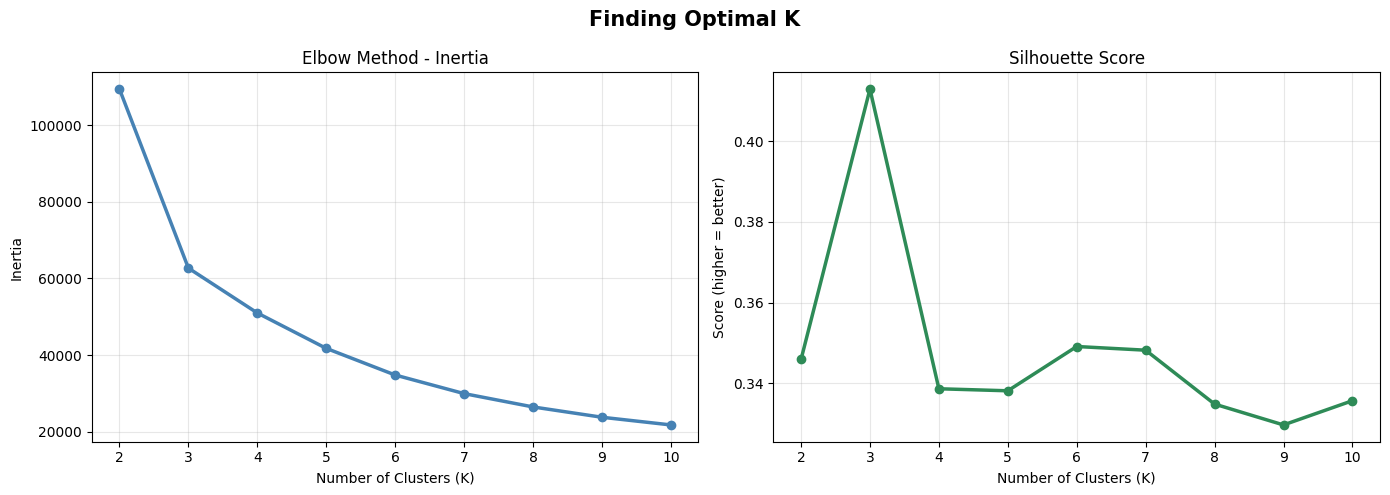

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal K', fontsize=15, fontweight='bold')

# Elbow Curve
axes[0].plot(K_range, inertia_values, marker='o', color='steelblue', linewidth=2.5)
axes[0].set_title('Elbow Method - Inertia')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_values, marker='o', color='seagreen', linewidth=2.5)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score (higher = better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Train with K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X)

# Attach cluster labels back to the clean rfm dataframe
rfm_clean['cluster'] = kmeans_final.labels_

print(rfm_clean['cluster'].value_counts())

cluster
1    38893
0    29980
2    14373
Name: count, dtype: int64


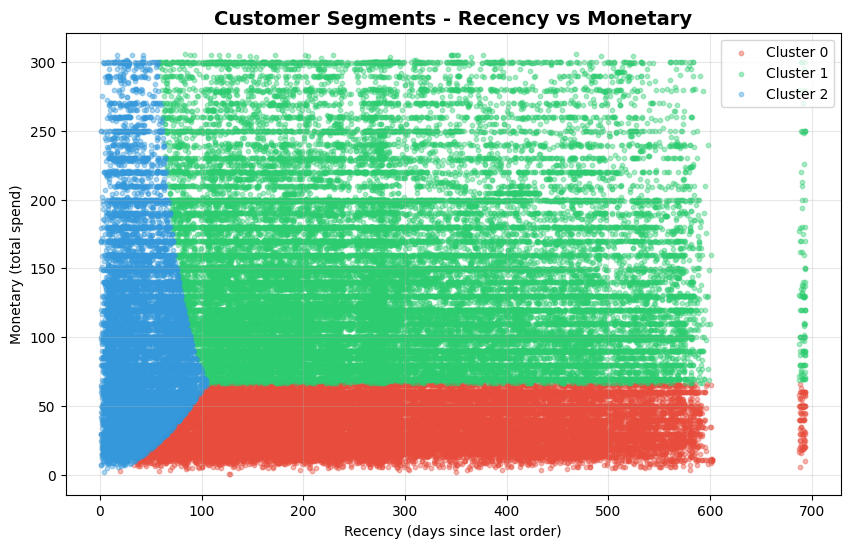

In [19]:
# Scatter plot of Recency vs Monetary colored by cluster
colors = ['#e74c3c', '#2ecc71', '#3498db']
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

plt.figure(figsize=(10, 6))

for cluster_id in sorted(rfm_clean['cluster'].unique()):
    subset = rfm_clean[rfm_clean['cluster'] == cluster_id]
    plt.scatter(
        subset['recency'],
        subset['monetary'],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        alpha=0.4,
        s=10
    )

plt.title('Customer Segments - Recency vs Monetary', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days since last order)')
plt.ylabel('Monetary (total spend)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Average RFM values per cluster (on original unscaled data)
profile = rfm_clean.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(1)
print(profile)

         recency  frequency  monetary
cluster                              
0          280.8        1.0      37.8
1          278.0        1.0     138.7
2           40.4        1.0      92.8


In [21]:
# Map cluster numbers to business names
cluster_labels = {
    0: 'Lost Cheap',
    1: 'Lapsed High-Value',
    2: 'Active Customers'
}

rfm_clean['segment'] = rfm_clean['cluster'].map(cluster_labels)

# Final summary
print(rfm_clean['segment'].value_counts())
print()
print(rfm_clean.groupby('segment')[['recency', 'monetary']].mean().round(1))

segment
Lapsed High-Value    38893
Lost Cheap           29980
Active Customers     14373
Name: count, dtype: int64

                   recency  monetary
segment                             
Active Customers      40.4      92.8
Lapsed High-Value    278.0     138.7
Lost Cheap           280.8      37.8


In [22]:
import joblib
import json

# Save the KMeans model
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')

# Save the scaler (must use the same scaling on new data)
joblib.dump(scaler, '../models/scaler.pkl')

# Save the IQR bounds so you can validate inputs on the website
iqr_bounds = {}
for col in ['recency', 'monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_bounds[col] = {
        'lower': Q1 - 1.5 * IQR,
        'upper': Q3 + 1.5 * IQR
    }

with open('../models/iqr_bounds.json', 'w') as f:
    json.dump(iqr_bounds, f)

# Save cluster label mapping
cluster_labels = {
    0: 'Lost Cheap',
    1: 'Lapsed High-Value',
    2: 'Active Customers'
}

with open('../models/cluster_labels.json', 'w') as f:
    json.dump(cluster_labels, f)

print("All artifacts saved.")
print("IQR bounds:", iqr_bounds)

All artifacts saved.
IQR bounds: {'recency': {'lower': np.float64(-234.0), 'upper': np.float64(694.0)}, 'monetary': {'lower': np.float64(-112.98125000000002), 'upper': np.float64(315.36875000000003)}}


## Summary

This project applied unsupervised learning to segment 83,246 Olist customers using RFM features. The pipeline covered multi-table joins, feature engineering, outlier removal, log transformation, feature scaling, K selection via Elbow and Silhouette methods, and K-Means clustering.

### Final Segments

| Segment | Count | Avg Recency | Avg Spend | Business Meaning |
|---|---|---|---|---|
| Lapsed High-Value | 38,893 | 278 days | $138.70 | High spenders who have gone quiet. Priority win-back target. |
| Lost Cheap | 29,980 | 281 days | $37.80 | Low spend, long gone. Low priority reactivation. |
| Active Customers | 14,373 | 40 days | $92.80 | Recently engaged. Nurture and upsell. |

### Key Findings

- Recency was the dominant separator. Active Customers stood out purely because they bought within the last 40 days on average, versus 278-281 days for inactive groups.
- Frequency was dropped entirely. Over 90% of customers purchased exactly once, leaving the feature with near-zero variance after log transform. Keeping it would have added noise without signal.
- Lapsed High-Value is the most commercially interesting segment. These 38,893 customers spent an average of $138.70 and were once engaged. A win-back campaign here has the highest potential return.
- K=3 was confirmed by both methods. The Elbow curve bent sharply at K=3 and Silhouette score peaked at 0.4129, dropping to around 0.33 for every higher K.

### Saved Artifacts

| File | Description |
|---|---|
| `models/kmeans_model.pkl` | Trained K-Means model (K=3) |
| `models/scaler.pkl` | Fitted StandardScaler for preprocessing new data |
| `models/iqr_bounds.json` | IQR clip bounds used during outlier removal |
| `models/cluster_labels.json` | Mapping from cluster IDs to business segment names |